# Dynamic Breakpoints
## Review
We discussed motivations for `human-in-the-loop`:
1. `Approval` - We can interrupt our agent, surface state to a user, and allow the user to accept an action.
2. `Debugging` - We can rewind the graph to reproduce or avoid issues.
3. `Editing` - You can modify the state.

We covered breakpoints as a general way (`edit_state_human_feedback.ipynb`) to stop the graph as specific steps, which enables use-cases like `Approval`.
We also showed how to edit graph state, and introduce human feedback.

## Goals
Breakpoints are set by the developer on a specific node during graph compilation. 

But, sometimes it is helpful to allow the graph dynamically interrupt itself. This is an internal breakpoint, and can be achieved using `NodeInterrupt`.

This has a few specific benefits:
1. You can do it conditionally (from inside a node based on developer-defined logic).
2. You can communicate to the user why it's interrupted (by passing whatever you want to `NodeInterrupt`).

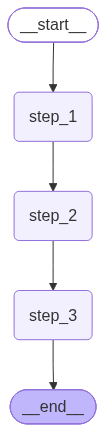

In [6]:
from IPython.display import Image, display

from typing_extensions import TypedDict
from langgraph.checkpoint.memory import MemorySaver
from langgraph.errors import NodeInterrupt
from langgraph.graph import START, END, StateGraph

class State(TypedDict):
    input: str

def step_1(state: State) -> State:
    print("---Step 1---")
    return state

def step_2(state: State) -> State:
    if len(state["input"]) > 5:
        raise NodeInterrupt(f"Received input that is longer than 5 chars: {state["input"]}")
    print("---Step 2---")
    return state

def step_3(state: State) -> State:
    print("---Step 3---")
    return state

# Build the graph
builder = StateGraph(State)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

# Logic
builder.add_edge(START, "step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# View
display(Image(graph.get_graph().draw_mermaid_png()))

Let's run the graph with an input that's longer than 5 characters.

If we inspect the graph state at this point, we can see the node set to execute next `step_2`.

In [7]:
initial_input = {"input": "Hello World!"}
thread_config = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread_config, stream_mode="values"):
    print(event)

state = graph.get_state(thread_config)
print("-"*50)
print(state.next)

{'input': 'Hello World!'}
---Step 1---
{'input': 'Hello World!'}
{'input': 'Hello World!', '__interrupt__': (Interrupt(value='Received input that is longer than 5 chars: Hello World!', id='placeholder-id'),)}
--------------------------------------------------
('step_2',)


/var/folders/lx/bt6372hd2fq1t__yfh69dpyc0000gn/T/ipykernel_77542/2998056115.py:17: LangGraphDeprecatedSinceV10: NodeInterrupt is deprecated. Please use `langgraph.types.interrupt` instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  raise NodeInterrupt(f"Received input that is longer than 5 chars: {state["input"]}")


We can try to resume the graph from the breakpoint. But this just re-runs the same node. Unless state is changed we will be stuck here.

In [8]:
for event in graph.stream(None, thread_config, stream_mode="values"):
    print(event)

state = graph.get_state(thread_config)
print("-"*50)
print(state.next)

{'input': 'Hello World!'}
{'input': 'Hello World!', '__interrupt__': (Interrupt(value='Received input that is longer than 5 chars: Hello World!', id='placeholder-id'),)}
--------------------------------------------------
('step_2',)


/var/folders/lx/bt6372hd2fq1t__yfh69dpyc0000gn/T/ipykernel_77542/2998056115.py:17: LangGraphDeprecatedSinceV10: NodeInterrupt is deprecated. Please use `langgraph.types.interrupt` instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  raise NodeInterrupt(f"Received input that is longer than 5 chars: {state["input"]}")


Now, we can update the state.

In [9]:
graph.update_state(thread_config, {"input": "hi"})

for event in graph.stream(None, thread_config, stream_mode="values"):
    print(event)

{'input': 'hi'}
---Step 2---
{'input': 'hi'}
---Step 3---
{'input': 'hi'}
